# Cross-dataset malaria classification: exploratory data analysis

Training set NIH (Bangladesh), test sets BBBC041 (Broad) and MP-IDB (CHUV Lausanne).

The project claims the three datasets are different imaging environments and that
a model trained on one will degrade on the others. This notebook measures that
claim instead of asserting it, and answers the questions raised after the proposal
presentation:

- **image intensity and size** across the datasets;
- **the actual differences in lighting, blur and staining** between them, ranked,
  so the RQ2 stress test can be aimed at the factors that really differ;
- **dataset 1 characterised properly**, since the NIH held-out score is the
  baseline every cross-dataset drop is measured against.

Cells are read through the manifests built by `scripts/build_crops.py`, which cut
BBBC041 and MP-IDB cells with one fixed rule (see `malaria/crops.py`). Statistics
come from `scripts/compute_stats.py`. Both must be run before this notebook.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from malaria import paths, plots
from malaria.imagestats import CENTER_FEATURES, FEATURES, domain_gap_table
from malaria.manifests import load_manifest
from malaria.splits import (build_nih_split, check_no_patient_leakage,
                            split_summary)

plots.set_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)

In [2]:
stats = pd.read_csv(paths.TABLES / "cell_stats.csv", low_memory=False)
stats = plots.add_domain(stats)
print(f"{len(stats):,} cells x {stats.shape[1]} columns")
print(f"domains: {plots.domains_in(stats)}")

115,030 cells x 41 columns
domains: ['nih', 'bbbc041/site_a', 'bbbc041/site_b', 'mpidb/Falciparum', 'mpidb/Malariae', 'mpidb/Ovale', 'mpidb/Vivax']


## A. What is actually in each dataset

Two things this table has to make explicit. First, BBBC041 ships two annotation
files that are two different acquisition batches (1208 images at 1200x1600 PNG,
120 at 1383x1944 JPG), so they are kept apart throughout as `site_a` and `site_b`.
Second, the parasite classes are rare: BBBC041 is overwhelmingly uninfected red
blood cells, and several MP-IDB stage/species cells number in the single digits.
That decides which per-class claims RQ3 can support.

In [3]:
inv = (stats.groupby(["dataset", "source_split", "eval_group"], observed=True)
            .size().rename("cells").reset_index())
print(inv.to_string(index=False))
print()
print("class balance within the primary evaluation set:")
prim = stats[stats.eval_group == "primary"]
print(pd.crosstab(prim["domain"], prim["label_binary"],
                  margins=True, dropna=False).to_string())

dataset source_split         eval_group  cells
bbbc041       site_a excluded_difficult    441
bbbc041       site_a excluded_leukocyte    103
bbbc041       site_a            primary  79569
bbbc041       site_b excluded_difficult      5
bbbc041       site_b            primary   5917
  mpidb   Falciparum            primary   1297
  mpidb     Malariae            primary     43
  mpidb        Ovale            primary     33
  mpidb        Vivax            primary     64
    nih  parasitized            primary  13779
    nih   uninfected            primary  13779

class balance within the primary evaluation set:
label_binary        0.0    1.0     All
domain                                
nih               13779  13779   27558
bbbc041/site_a    77420   2149   79569
bbbc041/site_b     5614    303    5917
mpidb/Falciparum      0   1297    1297
mpidb/Malariae        0     43      43
mpidb/Ovale           0     33      33
mpidb/Vivax           0     64      64
All               96813  17668  114

In [4]:
# Source-image structure of the test sets. RQ3 recall is estimated on cells that
# cluster within slide images, so the image count is the effective sample size
# for anything that varies between slides, and per-class intervals should be
# clustered by source image rather than treating every cell as independent.
test = stats[stats.dataset != "nih"]
per_img = (test.groupby(["domain", "source_image"], observed=True)
           .agg(cells=("cell_id", "size"),
                parasites=("label_binary", lambda s: int((s == 1).sum())))
           .reset_index())
by_dom = per_img.groupby("domain", observed=True)
img = pd.DataFrame({
    "images": by_dom.size(),
    "images_with_parasite": by_dom["parasites"].apply(lambda s: int((s > 0).sum())),
    "cells_per_image_median": by_dom["cells"].median(),
    "parasites_per_image_median": by_dom["parasites"].apply(
        lambda s: float(s[s > 0].median())),
})
print("test-set structure by source image:")
print(img.to_string())

# Crops clipped by the image edge come out smaller and non-square; they are kept
# and flagged rather than dropped, so the rate is reported here.
border = test["at_border"].astype(str).str.lower().eq("true")
print()
print("crops clipped by the image edge (at_border):")
print(border.groupby(test["domain"], observed=True).agg(rate="mean", n="sum")
      .round(4).to_string())

test-set structure by source image:
                  images  images_with_parasite  cells_per_image_median  parasites_per_image_median
domain                                                                                            
bbbc041/site_a      1208                   888                    59.0                         2.0
bbbc041/site_b       120                   115                    49.0                         2.0
mpidb/Falciparum     104                   104                     8.5                         8.5
mpidb/Malariae        37                    37                     1.0                         1.0
mpidb/Ovale           29                    29                     1.0                         1.0
mpidb/Vivax           40                    40                     1.0                         1.0

crops clipped by the image edge (at_border):
                    rate     n
domain                        
bbbc041/site_a    0.0601  4817
bbbc041/site_b    0.0679   402
mp

In [5]:
# Parasite stage / species counts -- the sample sizes RQ3 has to live with.
par = stats[(stats.label_binary == 1) & stats.stage.notna()]
tab = pd.crosstab(par["domain"], par["stage"], dropna=False)
tab["total"] = tab.sum(axis=1)
print(tab.to_string())
print()
small = tab.drop(columns="total").stack()
small = small[(small > 0) & (small < 30)].sort_values()
print("stage/domain cells with n < 30 (too few for a stable recall estimate):")
print(small.to_string())

stage             gametocyte  ring  schizont  trophozoite  unknown  total
domain                                                                   
nih                        0     0         0            0        0      0
bbbc041/site_a           144   353       179         1473        0   2149
bbbc041/site_b            12   169        11          111        0    303
mpidb/Falciparum           7  1230        18           42        0   1297
mpidb/Malariae             8     0        10           21        4     43
mpidb/Ovale                6    10         1            9        7     33
mpidb/Vivax                8    40        11            5        0     64

stage/domain cells with n < 30 (too few for a stable recall estimate):
domain            stage      
mpidb/Ovale       schizont        1
mpidb/Malariae    unknown         4
mpidb/Vivax       trophozoite     5
mpidb/Ovale       gametocyte      6
mpidb/Falciparum  gametocyte      7
mpidb/Ovale       unknown         7
mpidb/Malariae  

In [6]:
# Wilson intervals show how little these small classes can support. A class with
# n=7 cannot distinguish 'the model catches gametocytes' from 'it misses half'.
from statsmodels.stats.proportion import proportion_confint as _ci  # noqa

def wilson_width(n, p=0.9):
    if n == 0:
        return np.nan
    lo, hi = _ci(int(round(p * n)), n, method="wilson")
    return hi - lo

rows = [{"domain": d, "stage": s, "n": int(n),
         "recall_95CI_width_at_90pct": round(wilson_width(int(n)), 3)}
        for (d, s), n in tab.drop(columns="total").stack().items() if n > 0]
print(pd.DataFrame(rows).sort_values("n").to_string(index=False))

          domain       stage    n  recall_95CI_width_at_90pct
     mpidb/Ovale    schizont    1                       0.793
  mpidb/Malariae     unknown    4                       0.490
     mpidb/Vivax trophozoite    5                       0.588
     mpidb/Ovale  gametocyte    6                       0.533
     mpidb/Ovale     unknown    7                       0.487
mpidb/Falciparum  gametocyte    7                       0.487
     mpidb/Vivax  gametocyte    8                       0.448
  mpidb/Malariae  gametocyte    8                       0.448
     mpidb/Ovale trophozoite    9                       0.415
     mpidb/Ovale        ring   10                       0.386
  mpidb/Malariae    schizont   10                       0.386
  bbbc041/site_b    schizont   11                       0.361
     mpidb/Vivax    schizont   11                       0.361
  bbbc041/site_b  gametocyte   12                       0.339
mpidb/Falciparum    schizont   18                       0.297
  mpidb/

## B. Dataset 1: NIH structure and a defensible split

NIH filenames carry the slide the cell was cut from (the `C###` prefix). Cells
from one slide share a patient, a staining session and a lighting setup, so a
random split scores the model partly on having memorised a slide. Every
cross-dataset drop in this project is measured against the NIH held-out number,
so that baseline is split by slide instead.

The second panel is the more uncomfortable one. NIH negatives do not all come
from the same slides as the positives: a block of uninfected cells comes from
slides that contributed no parasitised cells at all. If those slides look
different, a model can separate the classes partly by recognising the slide
rather than the parasite, which would inflate the within-dataset baseline.

In [7]:
nih = stats[stats.dataset == "nih"].copy()
per_slide = nih.groupby("patient_id", observed=True).agg(
    cells=("cell_id", "size"), parasitised=("label_binary", "mean"))
print(f"unique slide/patient prefixes: {len(per_slide)}")
print(per_slide["cells"].describe().round(1).to_string())
print()
print("slides by class composition:")
print(pd.cut(per_slide["parasitised"], [-0.01, 0.001, 0.999, 1.01],
             labels=["uninfected cells only", "mixed", "parasitised only"])
      .value_counts().to_string())

unique slide/patient prefixes: 200
count    200.0
mean     137.8
std      126.9
min       65.0
25%       70.0
50%       85.5
75%      131.2
max      702.0

slides by class composition:
parasitised
mixed                    150
uninfected cells only     50
parasitised only           0


In [8]:
# Do the uninfected-only slides look different from the uninfected cells that
# come from slides which also contain parasites? If they do, part of the NIH
# class boundary is a slide-appearance boundary rather than a parasite boundary.
mixed_slides = set(per_slide.index[(per_slide.parasitised > 0) &
                                   (per_slide.parasitised < 1)])
neg = nih[nih.label_binary == 0].copy()
neg["slide_type"] = np.where(neg.patient_id.isin(mixed_slides),
                             "negative from mixed slide",
                             "negative from uninfected-only slide")
cols = ["gray_mean", "gray_std", "sat_mean", "rb_diff", "lapvar224", "black_frac"]
print(neg.groupby("slide_type")[cols].median().round(2).to_string())
print()
print(neg["slide_type"].value_counts().to_string())

from malaria.imagestats import cohens_d
a = neg[neg.slide_type.str.contains("uninfected-only")]
b = neg[neg.slide_type.str.contains("mixed")]
print()
print("Cohen's d, uninfected-only slides vs mixed slides:")
for c in cols:
    print(f"  {c:14s} d = {cohens_d(np.asarray(a[c]), np.asarray(b[c])):+.3f}")

                                     gray_mean  gray_std  sat_mean  rb_diff  lapvar224  black_frac
slide_type                                                                                        
negative from mixed slide               120.42     73.99     45.55    32.64     570.76        0.26
negative from uninfected-only slide     127.29     73.76     17.03    -3.00     576.71        0.24

slide_type
negative from mixed slide              10364
negative from uninfected-only slide     3415

Cohen's d, uninfected-only slides vs mixed slides:
  gray_mean      d = +0.588
  gray_std       d = +0.050
  sat_mean       d = -1.120
  rb_diff        d = -0.897
  lapvar224      d = +0.089
  black_frac     d = -0.346


In [9]:
# Is that difference actually exploitable? Predict the NIH label from colour
# alone -- no shape, no texture -- grouped by slide so the classifier cannot
# simply memorise a slide. Then repeat on mixed slides only, where every cell has
# a same-slide counterpart of the other class and the slide-composition effect is
# removed by construction. A large gap between the two would mean the class
# boundary is partly 'which slide is this'.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

COLOUR = ["r_mean", "g_mean", "b_mean", "rb_diff", "sat_mean", "hue_mean",
          "gray_mean_center"]

def label_auc(df, feats=COLOUR):
    X = df[feats].to_numpy(float)
    y = df["label_binary"].to_numpy(int)
    g = df["patient_id"].astype(str).to_numpy()
    clf = RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                 n_jobs=-1, random_state=0)
    p = cross_val_predict(clf, X, y, groups=g, cv=GroupKFold(n_splits=5),
                          method="predict_proba")[:, 1]
    return roc_auc_score(y, p)

mixed_only = nih[nih.patient_id.isin(mixed_slides)]
print("NIH label predicted from colour alone (grouped by slide):")
print(f"  all cells            AUC = {label_auc(nih):.4f}   n = {len(nih):,}")
print(f"  mixed slides only    AUC = {label_auc(mixed_only):.4f}   n = {len(mixed_only):,}")

NIH label predicted from colour alone (grouped by slide):


  all cells            AUC = 0.7714   n = 27,558


  mixed slides only    AUC = 0.7526   n = 24,143


Two things follow, and they point in different directions.

The uninfected-only slides really do look different: saturation d = -1.12 and the
red-minus-blue stain axis flips sign entirely. That is a large difference inside
what is nominally one class.

But it is mostly not what makes the classes separable. Removing those slides
barely moves the colour-only AUC (0.77 to 0.75), so the bulk of the colour signal
comes from parasitised cells genuinely carrying stained parasite material, which
is real morphology rather than a slide artefact. The honest reading is that NIH
does not have a large slide-identity shortcut, but that a colour-only model still
reaches about 0.77 AUC, so headline NIH accuracy should not be read as evidence
that a model has learned parasite morphology.

The split is grouped by slide regardless, which costs nothing and removes the
question.

In [10]:
manifest = load_manifest()
nih_split = build_nih_split(manifest)
check_no_patient_leakage(nih_split)
print("no slide appears in more than one split")
print()
print(split_summary(nih_split).round(4).to_string())
print()
print(f"written to {paths.MANIFESTS / 'nih_split.csv'}")

no slide appears in more than one split

       cells  patients  share_of_cells  parasitised_rate
split                                                   
train  19203       140          0.6968            0.5011
val     4178        30          0.1516            0.5019
test    4177        30          0.1516            0.4932

written to C:\Users\noaht\Downloads\Thesis\data\manifests\nih_split.csv


  saved outputs/figures/B_nih_slide_structure.png


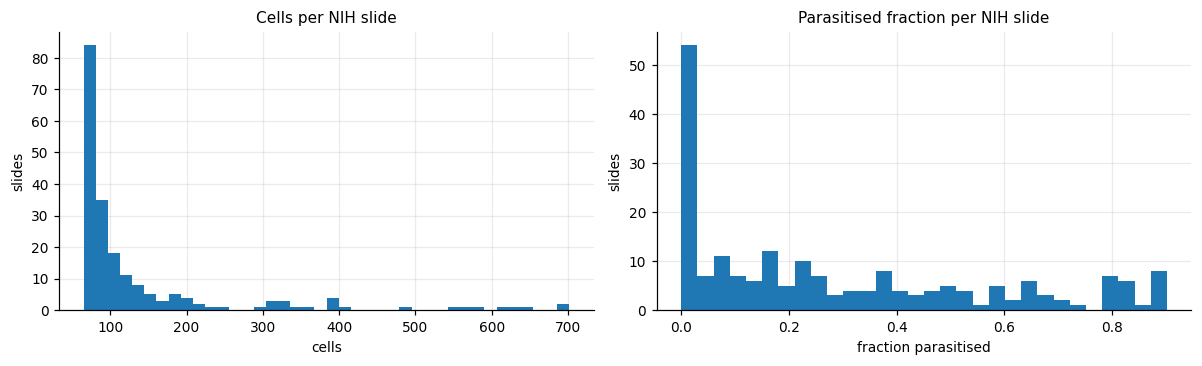

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(per_slide["cells"], bins=40, color=plots.DOMAIN_COLORS["nih"])
axes[0].set(title="Cells per NIH slide", xlabel="cells", ylabel="slides")
axes[1].hist(per_slide["parasitised"], bins=30,
             color=plots.DOMAIN_COLORS["nih"])
axes[1].set(title="Parasitised fraction per NIH slide",
            xlabel="fraction parasitised", ylabel="slides")
fig.tight_layout()
plots.save(fig, "B_nih_slide_structure")

### Duplicates, exact and near

Two checks, both read against the split. An exact duplicate is the same file
twice; a near duplicate is the same cell saved twice with different compression
or a one-pixel shift, which a perceptual hash catches and a byte hash does not.
Either kind straddling train and test would be leakage that no grouping prevents.

Perceptual hashes need care on this data. An uninfected red cell is a featureless
disc, and two featureless discs from different patients can share a hash without
being the same cell. So a hash match is only a candidate: a genuine repeat must
also come from the same patient, and the split is grouped by patient. The table
therefore reports every near match, and separately how many sit within one
patient, which is the only set that can be real repeats.

exact duplicates: 0 files in 0 groups


 hamming <=  hash matches  different class  different patient  same patient (possible repeats)  same patient, across splits
          0             2                1                  2                                0                            0
          2           152               54                151                                1                            0
          4          2910             1019               2878                               32                            0


  saved outputs/figures/B_near_duplicates.png


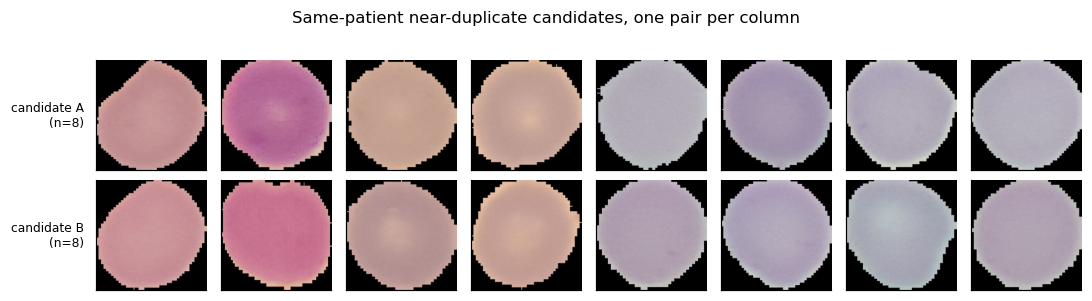

In [12]:
import hashlib
import imagehash
from PIL import Image

cells = nih_split.reset_index(drop=True)
md5, bits = {}, []
for cid, p in zip(cells["cell_id"], cells["path"]):
    full = paths.ROOT / p
    md5.setdefault(hashlib.md5(full.read_bytes()).hexdigest(), []).append(cid)
    with Image.open(full) as im:
        bits.append(imagehash.phash(im).hash.flatten())
exact = [v for v in md5.values() if len(v) > 1]
print(f"exact duplicates: {sum(len(v) for v in exact)} files in {len(exact)} groups")

# Hamming distance between every pair of 64-bit hashes, in blocks. Equal bits are
# ones in common plus zeros in common, which is two matrix products.
B = np.asarray(bits, dtype=np.float32)
del bits
ones, zeros = B.T.copy(), (1 - B).T.copy()   # hoisted out of the loop
BLOCK = 400   # keeps each temporary near 45 MB rather than 220 MB
pairs = []
for i0 in range(0, len(B), BLOCK):
    blk = B[i0:i0 + BLOCK]
    ham = 64 - (blk @ ones + (1 - blk) @ zeros)
    ii, jj = np.where(ham <= 4)
    pairs += [(i0 + a, int(b), int(round(ham[a, b])))
              for a, b in zip(ii, jj) if b > i0 + a]
    del ham
pairs = pd.DataFrame(pairs, columns=["i", "j", "d"])

sp = cells["split"].to_numpy()
pt = cells["patient_id"].astype(str).to_numpy()
lb = cells["label_binary"].astype(int).to_numpy()
rows = []
for thr in (0, 2, 4):
    s = pairs[pairs.d <= thr]
    i, j = s.i.to_numpy(), s.j.to_numpy()
    within = s[pt[i] == pt[j]]
    wi, wj = within.i.to_numpy(), within.j.to_numpy()
    rows.append({"hamming <=": thr, "hash matches": len(s),
                 "different class": int((lb[i] != lb[j]).sum()),
                 "different patient": int((pt[i] != pt[j]).sum()),
                 "same patient (possible repeats)": len(within),
                 "same patient, across splits": int((sp[wi] != sp[wj]).sum())})
print(pd.DataFrame(rows).to_string(index=False))

cand = pairs[pt[pairs.i.to_numpy()] == pt[pairs.j.to_numpy()]].sort_values("d").head(8)
if len(cand):
    fig = plots.contact_sheet(
        [("candidate A", cells.iloc[cand.i.to_numpy()]),
         ("candidate B", cells.iloc[cand.j.to_numpy()])],
        n=len(cand), sample=False,
        title="Same-patient near-duplicate candidates, one pair per column")
    plots.save(fig, "B_near_duplicates")

No file appears twice. The perceptual hash does produce matches, but they are
collisions between look-alike cells rather than repeats: at Hamming distance 4 or
less, nearly all of them join two different patients and about a third join a
parasitised cell to an uninfected one, which the same cell cannot do. The few
that sit within one patient are the only possible repeats, and they stay on one
side of the split by construction; the eight closest of them are shown above and
are visibly different cells. There is no duplicate leakage across train,
validation and test.

## C. Size

`upscale_factor` is the multiplier needed to reach the 224 px network input.
Above 1 the image is being invented by interpolation, and a cell that arrives at
4x upscale carries no more real detail than its original 55 px.

  saved outputs/figures/C_size.png
                      w      h     area  upscale_factor
domain                                                 
nih               130.0  130.0  17290.0            1.61
bbbc041/site_a    135.0  135.0  18360.0            1.65
bbbc041/site_b    172.0  172.0  29584.0            1.29
mpidb/Falciparum   78.0   78.0   6084.0            2.87
mpidb/Malariae    126.0  126.0  15876.0            1.78
mpidb/Ovale       138.0  138.0  19044.0            1.62
mpidb/Vivax       147.0  147.0  21609.0            1.52


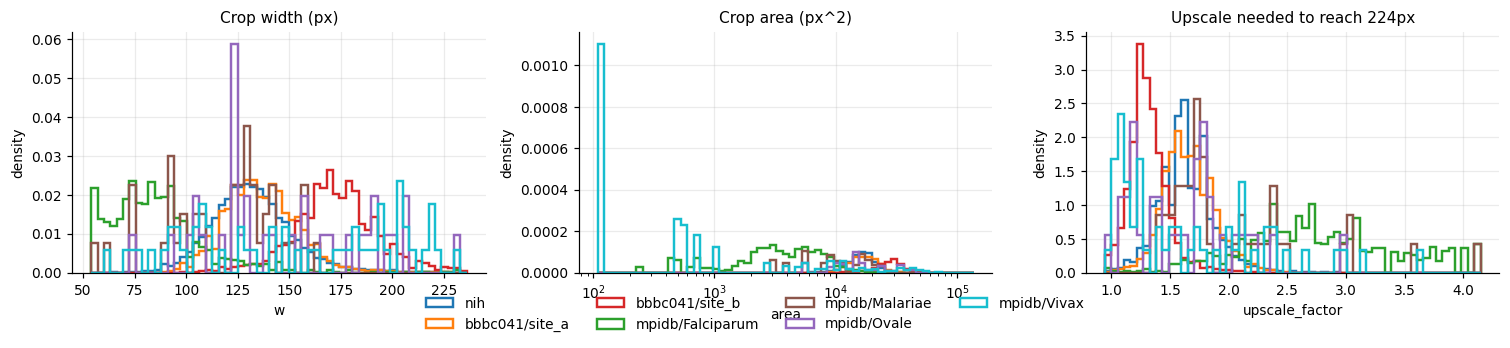

In [13]:
fig, _ = plots.feature_panels(
    stats, ["w", "area", "upscale_factor"],
    titles={"w": "Crop width (px)", "area": "Crop area (px^2)",
            "upscale_factor": f"Upscale needed to reach {paths.MODEL_INPUT}px"},
    log=("area",), ncols=3)
plots.save(fig, "C_size")

print(stats.groupby("domain", observed=True)[["w", "h", "area", "upscale_factor"]]
      .median().round(2).to_string())

                    count   mean   std   min     1%     5%    50%    max
domain                                                                  
nih               27558.0  126.0  17.0  40.0   85.0  100.0  124.0  340.0
bbbc041/site_a    80113.0  136.0  19.0  77.0   99.0  109.0  135.0  306.0
bbbc041/site_b     5922.0  173.0  23.0  98.0  118.0  140.0  172.0  370.0
mpidb/Falciparum   1297.0   80.0  28.0  15.0   25.0   44.0   78.0  268.0
mpidb/Malariae       43.0  118.0  27.0  54.0   57.0   73.0  126.0  162.0
mpidb/Ovale          33.0  148.0  39.0  75.0   81.0   98.0  138.0  231.0
mpidb/Vivax          64.0  145.0  63.0  10.0   18.0   28.0  147.0  267.0

MP-IDB crops with min side < 30 px: 29
                          cell_id stage  w  h  upscale_factor
        Vivax_1709041080-0020-R_0  ring 11 10           20.36
  Falciparum_1701151546-0014-R_17  ring 15 16           14.00
  Falciparum_1701151546-0014-R_22  ring 21 20           10.67
  Falciparum_1701151546-0014-R_49  ring 21 21          

  saved outputs/figures/C_smallest_crops.png


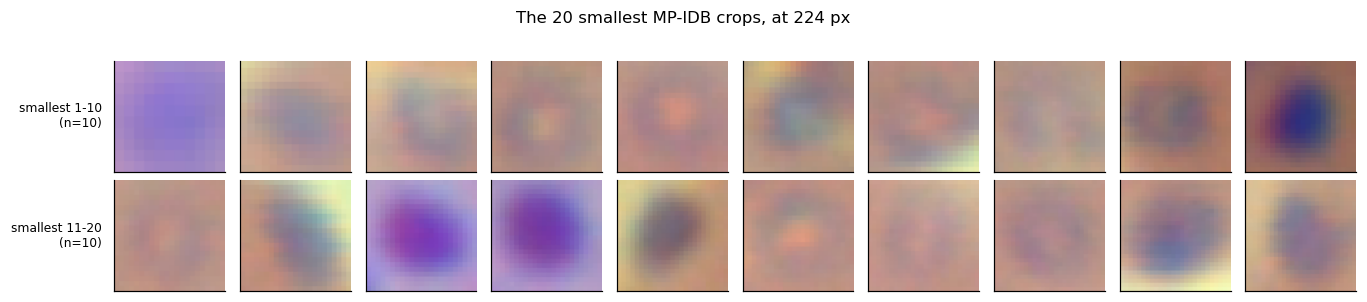

In [14]:
# The small end of the size distribution. A component 10 px across is upscaled
# more than 20x to reach the network input and carries no morphology, so it
# cannot be scored fairly; these are listed so RQ3 can hold them out the way
# BBBC041 'difficult' cells are, rather than absorb them silently.
small = stats.assign(min_side=stats[["w", "h"]].min(axis=1))
print(small.groupby("domain", observed=True)["min_side"]
      .describe(percentiles=[0.01, 0.05, 0.5]).round(0).to_string())

tiny = (small[(small.dataset == "mpidb") & (small.min_side < 30)]
        .sort_values("min_side"))
print()
print(f"MP-IDB crops with min side < 30 px: {len(tiny)}")
print(tiny[["cell_id", "stage", "w", "h", "upscale_factor"]]
      .round(2).to_string(index=False))

fig = plots.contact_sheet([("smallest 1-10", tiny.iloc[:10]),
                           ("smallest 11-20", tiny.iloc[10:20])],
                          n=10, sample=False,
                          title="The 20 smallest MP-IDB crops, at 224 px")
plots.save(fig, "C_smallest_crops")

## D. Intensity and lighting

`gray_mean` is overall brightness and `gray_std` is contrast, the two
quantities the follow-up e-mail asked for.

These have to be read twice, because NIH cells are segmented onto a black
background and roughly a quarter of every NIH crop is that padding. Whole-crop
brightness and contrast therefore partly describe the padding rather than the
cell. Both views are reported: the whole-crop numbers describe what the network
is fed, and the `_center` numbers, restricted to the central disc, describe the
imaging itself. The two disagree about NIH in opposite directions, so quoting
only the first would put the wrong conclusion in the thesis.

  saved outputs/figures/D_intensity.png
whole crop (what the network is fed) vs tissue only (the imaging):
                  gray_mean  gray_mean_center  gray_std  gray_std_center
domain                                                                  
nih                  118.55            164.21     73.37             5.06
bbbc041/site_a       152.32             91.73     66.15            22.91
bbbc041/site_b       132.06            121.94     14.32             3.28
mpidb/Falciparum     135.81            123.69     16.89            14.31
mpidb/Malariae       137.68             98.55     33.75            15.18
mpidb/Ovale          149.77            138.34     23.01            12.64
mpidb/Vivax          164.53            151.17     25.04            14.95


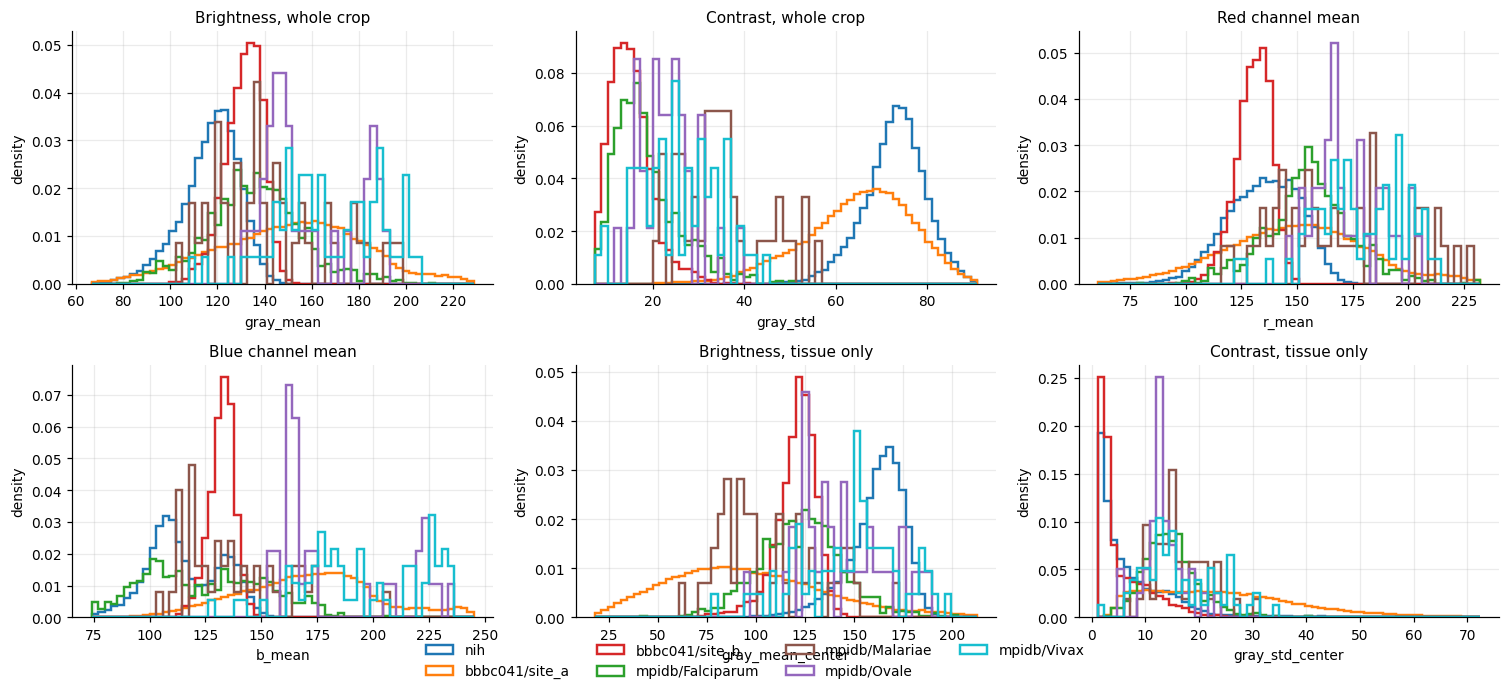

In [15]:
fig, _ = plots.feature_panels(
    stats, ["gray_mean", "gray_std", "r_mean", "b_mean",
            "gray_mean_center", "gray_std_center"],
    titles={"gray_mean": "Brightness, whole crop",
            "gray_std": "Contrast, whole crop",
            "r_mean": "Red channel mean", "b_mean": "Blue channel mean",
            "gray_mean_center": "Brightness, tissue only",
            "gray_std_center": "Contrast, tissue only"},
    ncols=3)
plots.save(fig, "D_intensity")

print("whole crop (what the network is fed) vs tissue only (the imaging):")
print(stats.groupby("domain", observed=True)
      [["gray_mean", "gray_mean_center", "gray_std", "gray_std_center"]]
      .median().round(2).to_string())

## E. Staining colour

Giemsa stain puts parasite chromatin in the purple/blue range, so saturation and
the red-minus-blue difference track the staining protocol and the white balance
of the capture device.

  saved outputs/figures/E_stain.png
                  sat_mean  rb_diff  hue_mean
domain                                       
nih                  45.33    29.10     90.29
bbbc041/site_a       56.79   -24.00    102.55
bbbc041/site_b       17.10    -1.59     84.73
mpidb/Falciparum     76.88    42.74     38.72
mpidb/Malariae       67.51    33.04     96.23
mpidb/Ovale          60.65    -2.40    145.80
mpidb/Vivax          55.18   -18.12    138.71


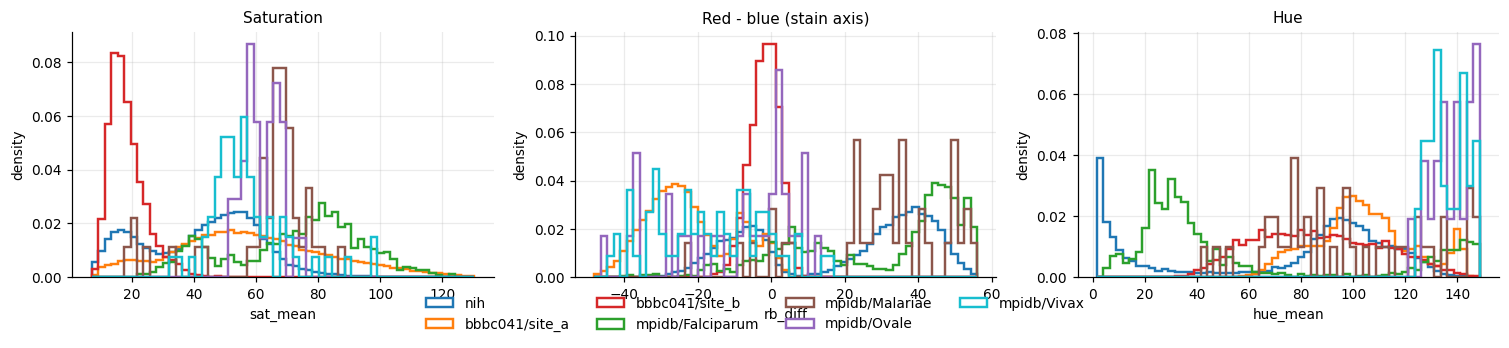

In [16]:
fig, _ = plots.feature_panels(
    stats, ["sat_mean", "rb_diff", "hue_mean"],
    titles={"sat_mean": "Saturation", "rb_diff": "Red - blue (stain axis)",
            "hue_mean": "Hue"}, ncols=3)
plots.save(fig, "E_stain")

print(stats.groupby("domain", observed=True)[["sat_mean", "rb_diff", "hue_mean"]]
      .median().round(2).to_string())

## F. Sharpness, and a trap in measuring it

Laplacian variance at the network input size. Measuring it natively would make a
2592 px slide look sharper than a 55 px crop purely because of pixel count, so
everything is compared at 224 px.

There is a second and larger trap. Measured over the whole crop, NIH scores about
575 against 3 to 35 for every test domain, which reads as NIH being one to two
orders of magnitude sharper. It is not. A Laplacian responds to any strong
gradient, and the hard boundary between an NIH cell and its black background is
the strongest gradient in the image. Restricted to the central disc, NIH scores
about 6, below BBBC041 site_a and in the same range as the rest. site_b, the
one JPEG domain, has the lowest tissue sharpness of all, and JPEG quantisation
smooths exactly the fine gradients a Laplacian measures, so part of that floor may
be compression rather than optics.

So the whole-crop figure measures the segmentation mask, not the optics. The
`_center` column is the one that answers the supervisor's question about blur
differences between datasets.

  saved outputs/figures/F_sharpness.png
                  lapvar224  lapvar224_center  black_frac  whole/tissue ratio
domain                                                                       
nih                  574.84              6.05        0.26                95.0
bbbc041/site_a        34.69             24.18        0.00                 1.4
bbbc041/site_b         2.81              2.49        0.00                 1.1
mpidb/Falciparum       5.67              7.72        0.00                 0.7
mpidb/Malariae        34.80             34.22        0.00                 1.0
mpidb/Ovale            5.33              5.24        0.00                 1.0
mpidb/Vivax            5.78              5.61        0.00                 1.0

The ratio tracks black_frac almost exactly: the inflation is the mask.


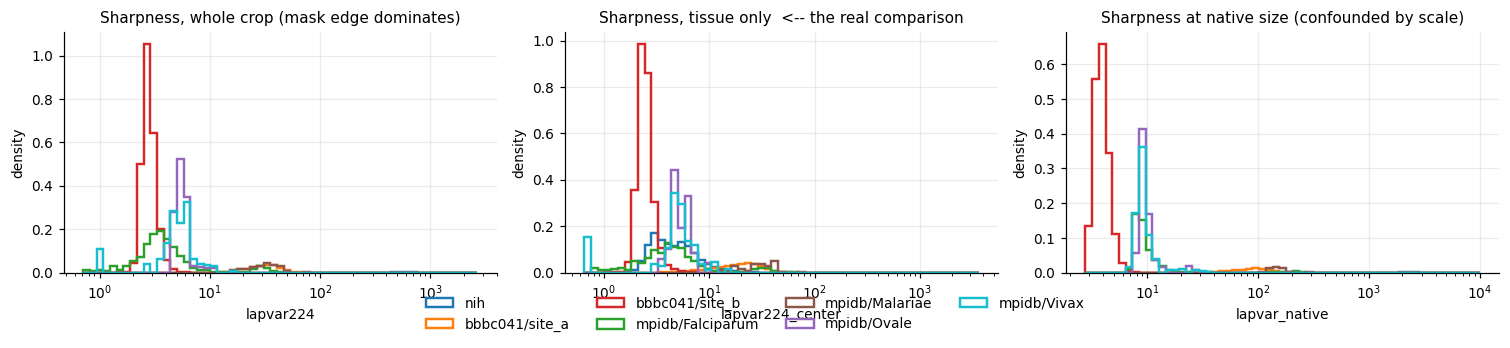

In [17]:
fig, _ = plots.feature_panels(
    stats, ["lapvar224", "lapvar224_center", "lapvar_native"],
    titles={"lapvar224": "Sharpness, whole crop (mask edge dominates)",
            "lapvar224_center": "Sharpness, tissue only  <-- the real comparison",
            "lapvar_native": "Sharpness at native size (confounded by scale)"},
    log=("lapvar224", "lapvar224_center", "lapvar_native"), ncols=3)
plots.save(fig, "F_sharpness")

sharp = (stats.groupby("domain", observed=True)
         [["lapvar224", "lapvar224_center", "black_frac"]].median().round(2))
sharp["whole/tissue ratio"] = (sharp.lapvar224 / sharp.lapvar224_center).round(1)
print(sharp.to_string())
print()
print("The ratio tracks black_frac almost exactly: the inflation is the mask.")

## G. Crop format: the largest single difference

NIH cells are segmented onto a black background. The two test sets cannot be:
BBBC041 ships bounding boxes with no masks, so masking MP-IDB alone would have
made its Falciparum crops resemble the training data while Vivax crops did not,
confounding the RQ3 species comparison with crop format. Both test sets therefore
get plain rectangles.

The consequence is a genuine train/test difference that is a property of the
sources rather than of the imaging: roughly a quarter of every NIH image is pure
black padding, and essentially none of a test image is. `black_frac_outer`
measures it where it lives, in the corners.

  saved outputs/figures/G_crop_format.png
                  black_frac  black_frac_outer  black_frac_center
domain                                                           
nih                    0.263             0.629                0.0
bbbc041/site_a         0.000             0.000                0.0
bbbc041/site_b         0.000             0.000                0.0
mpidb/Falciparum       0.000             0.000                0.0
mpidb/Malariae         0.000             0.000                0.0
mpidb/Ovale            0.000             0.000                0.0
mpidb/Vivax            0.000             0.000                0.0


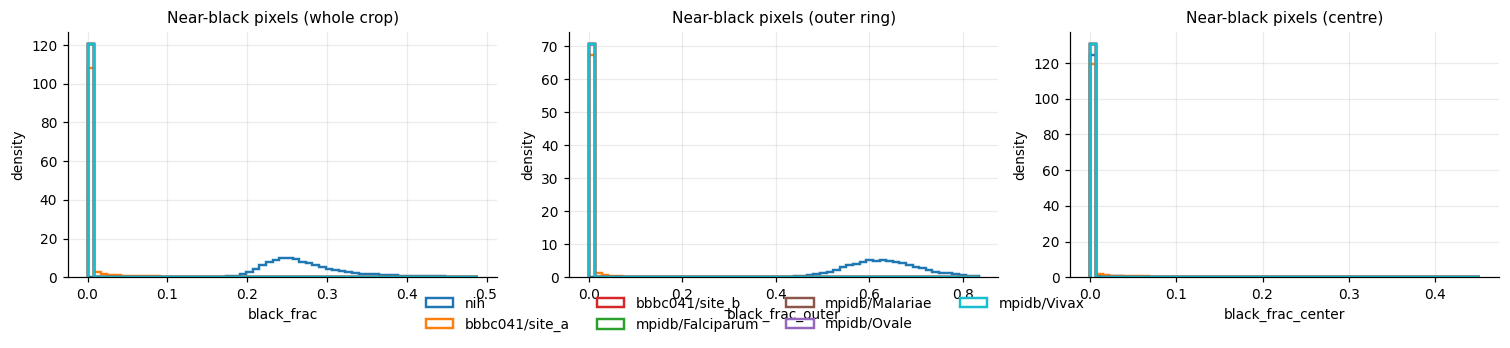

In [18]:
fig, _ = plots.feature_panels(
    stats, ["black_frac", "black_frac_outer", "black_frac_center"],
    titles={"black_frac": "Near-black pixels (whole crop)",
            "black_frac_outer": "Near-black pixels (outer ring)",
            "black_frac_center": "Near-black pixels (centre)"}, ncols=3)
plots.save(fig, "G_crop_format")

print(stats.groupby("domain", observed=True)
      [["black_frac", "black_frac_outer", "black_frac_center"]]
      .median().round(3).to_string())

## H. How far apart are the domains, and along which axis

Two measures on the feature table.

**Cohen's d** ranks the individual properties by how far each test domain sits
from NIH, in pooled standard deviations. This is what tells RQ2 which
degradations are worth sweeping.

**A domain classifier** asks whether the domains are separable at all from these
cheap features. It is grouped by source slide so it cannot pass by memorising a
slide. An AUC near 1.0 means a model does not need to be subtle to tell the
datasets apart, which is the premise of the whole project; it is reported twice,
once on all features and once with every size and mask-sensitive feature removed,
so the result is not just restating that the crops are different shapes.

Read the ranking from the top and the story is uncomfortable for the original
framing. The largest differences between NIH and every test set are crop-format
artefacts: the black padding (`black_frac_outer`, `gray_p5`) and native
resolution (`lapvar_native`). Lighting and focus sit far below them. Once measured
on tissue only, sharpness is nearly identical across all seven domains
(`lapvar224_center`, largest |d| about 0.3) and contrast differences shrink by
roughly sevenfold. What genuinely differs is colour and brightness.

In [19]:
gap = domain_gap_table(stats, reference="nih", group_col="domain")
print("Cohen's d vs NIH (positive = test domain is higher)")
print(gap.round(2).to_string())
gap.round(4).to_csv(paths.TABLES / "domain_gap_cohens_d.csv")

Cohen's d vs NIH (positive = test domain is higher)
                   bbbc041/site_a  bbbc041/site_b  mpidb/Falciparum  mpidb/Malariae  mpidb/Ovale  mpidb/Vivax  max_abs_d
gray_p5                      2.11           20.93             24.44           85.88       169.83       138.02     169.83
black_frac_outer           -15.24           -8.78             -8.15           -7.97        -7.97        -7.98      15.24
lapvar_native              -12.32           -8.61             -7.71           -7.31        -7.80        -7.80      12.32
gray_std                    -0.74           -9.15             -8.19           -5.70        -7.49        -7.10       9.15
lapvar224                   -8.81           -5.78             -5.25           -4.95        -5.22        -5.22       8.81
black_frac                  -7.52           -5.08             -4.72           -4.61        -4.61        -4.62       7.52
gray_p95                     4.89           -3.10             -1.21            1.83         2.38     

  saved outputs/figures/H_domain_gap.png


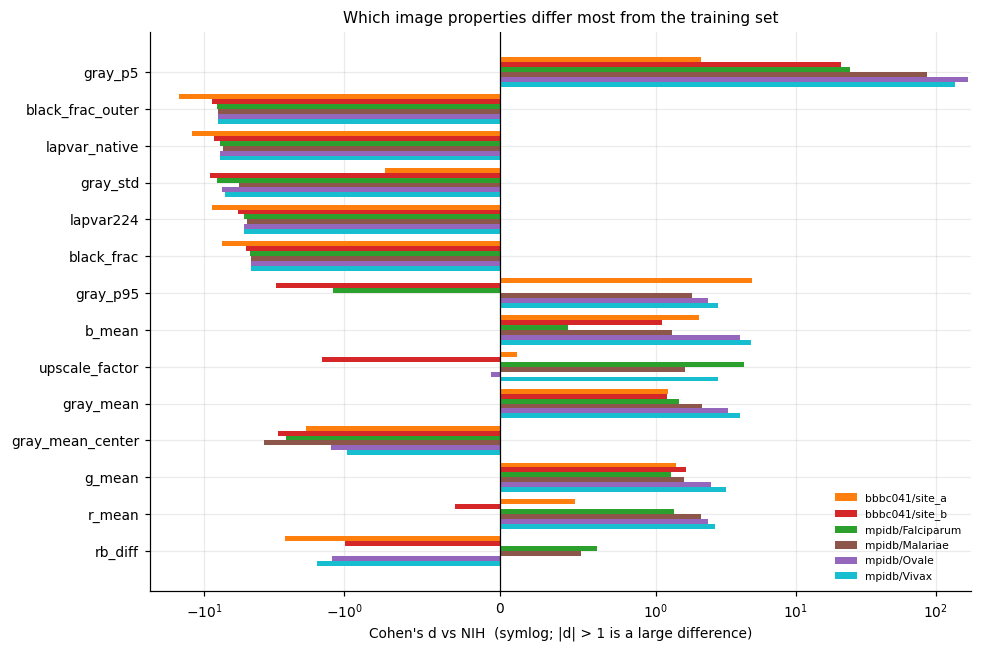

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
top = gap.drop(columns="max_abs_d").head(14)
y = np.arange(len(top))
width = 0.8 / max(1, top.shape[1])
for i, col in enumerate(top.columns):
    ax.barh(y + i * width, top[col], height=width, label=col,
            color=plots.DOMAIN_COLORS.get(col))
ax.set_yticks(y + 0.4 - width / 2)
ax.set_yticklabels(top.index)
ax.invert_yaxis()
ax.axvline(0, color="k", lw=0.8)
# symlog, because gray_p5 reaches |d| ~ 170: NIH's 5th percentile is exactly 0
# for every masked crop, so its variance collapses and the ratio explodes. On a
# linear axis that one degenerate feature flattens every other bar to nothing.
ax.set_xscale("symlog", linthresh=1)
ax.set_xlabel("Cohen's d vs NIH  (symlog; |d| > 1 is a large difference)")
ax.set_title("Which image properties differ most from the training set")
ax.legend(fontsize=7, loc="lower right")
fig.tight_layout()
plots.save(fig, "H_domain_gap")

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

# Everything that encodes crop geometry or the segmentation mask is removed, so
# the second AUC cannot be won just by noticing that NIH crops have black corners.
APPEARANCE_ONLY = [f for f in FEATURES if f not in
                   {"w", "h", "area", "aspect", "upscale_factor",
                    "black_frac", "black_frac_outer", "black_frac_center",
                    "lapvar_native", "gray_mean", "gray_std", "lapvar224",
                    "gray_p5", "gray_p50", "gray_p95"}]
print("appearance-only features:", APPEARANCE_ONLY)

def domain_auc(target, features):
    sub = stats[stats.domain.astype(str).isin(["nih", target])]
    X = sub[features].to_numpy(float)
    y = (sub.domain.astype(str) == target).astype(int).to_numpy()
    groups = sub["source_image"].astype(str).to_numpy()
    n_splits = min(5, len(np.unique(groups)))
    clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                 n_jobs=-1, random_state=0)
    p = cross_val_predict(clf, X, y, groups=groups,
                          cv=GroupKFold(n_splits=n_splits),
                          method="predict_proba")[:, 1]
    return roc_auc_score(y, p)

rows = []
for target in plots.domains_in(stats):
    if target == "nih":
        continue
    rows.append({"domain": target,
                 "AUC_all_features": round(domain_auc(target, FEATURES), 4),
                 "AUC_appearance_only": round(domain_auc(target, APPEARANCE_ONLY), 4)})
auc = pd.DataFrame(rows)
print("Can a cheap classifier tell this domain from NIH? (grouped by slide)")
print(auc.to_string(index=False))
auc.to_csv(paths.TABLES / "domain_classifier_auc.csv", index=False)

appearance-only features: ['r_mean', 'g_mean', 'b_mean', 'rb_diff', 'sat_mean', 'hue_mean', 'gray_mean_center', 'gray_std_center', 'lapvar224_center']


Can a cheap classifier tell this domain from NIH? (grouped by slide)
          domain  AUC_all_features  AUC_appearance_only
  bbbc041/site_a               1.0               1.0000
  bbbc041/site_b               1.0               1.0000
mpidb/Falciparum               1.0               1.0000
  mpidb/Malariae               1.0               0.9998
     mpidb/Ovale               1.0               1.0000
     mpidb/Vivax               1.0               1.0000


## I. What the network actually sees

Every crop rendered at 224 px, which is the only fair way to compare them.

  saved outputs/figures/I_contact_sheet.png


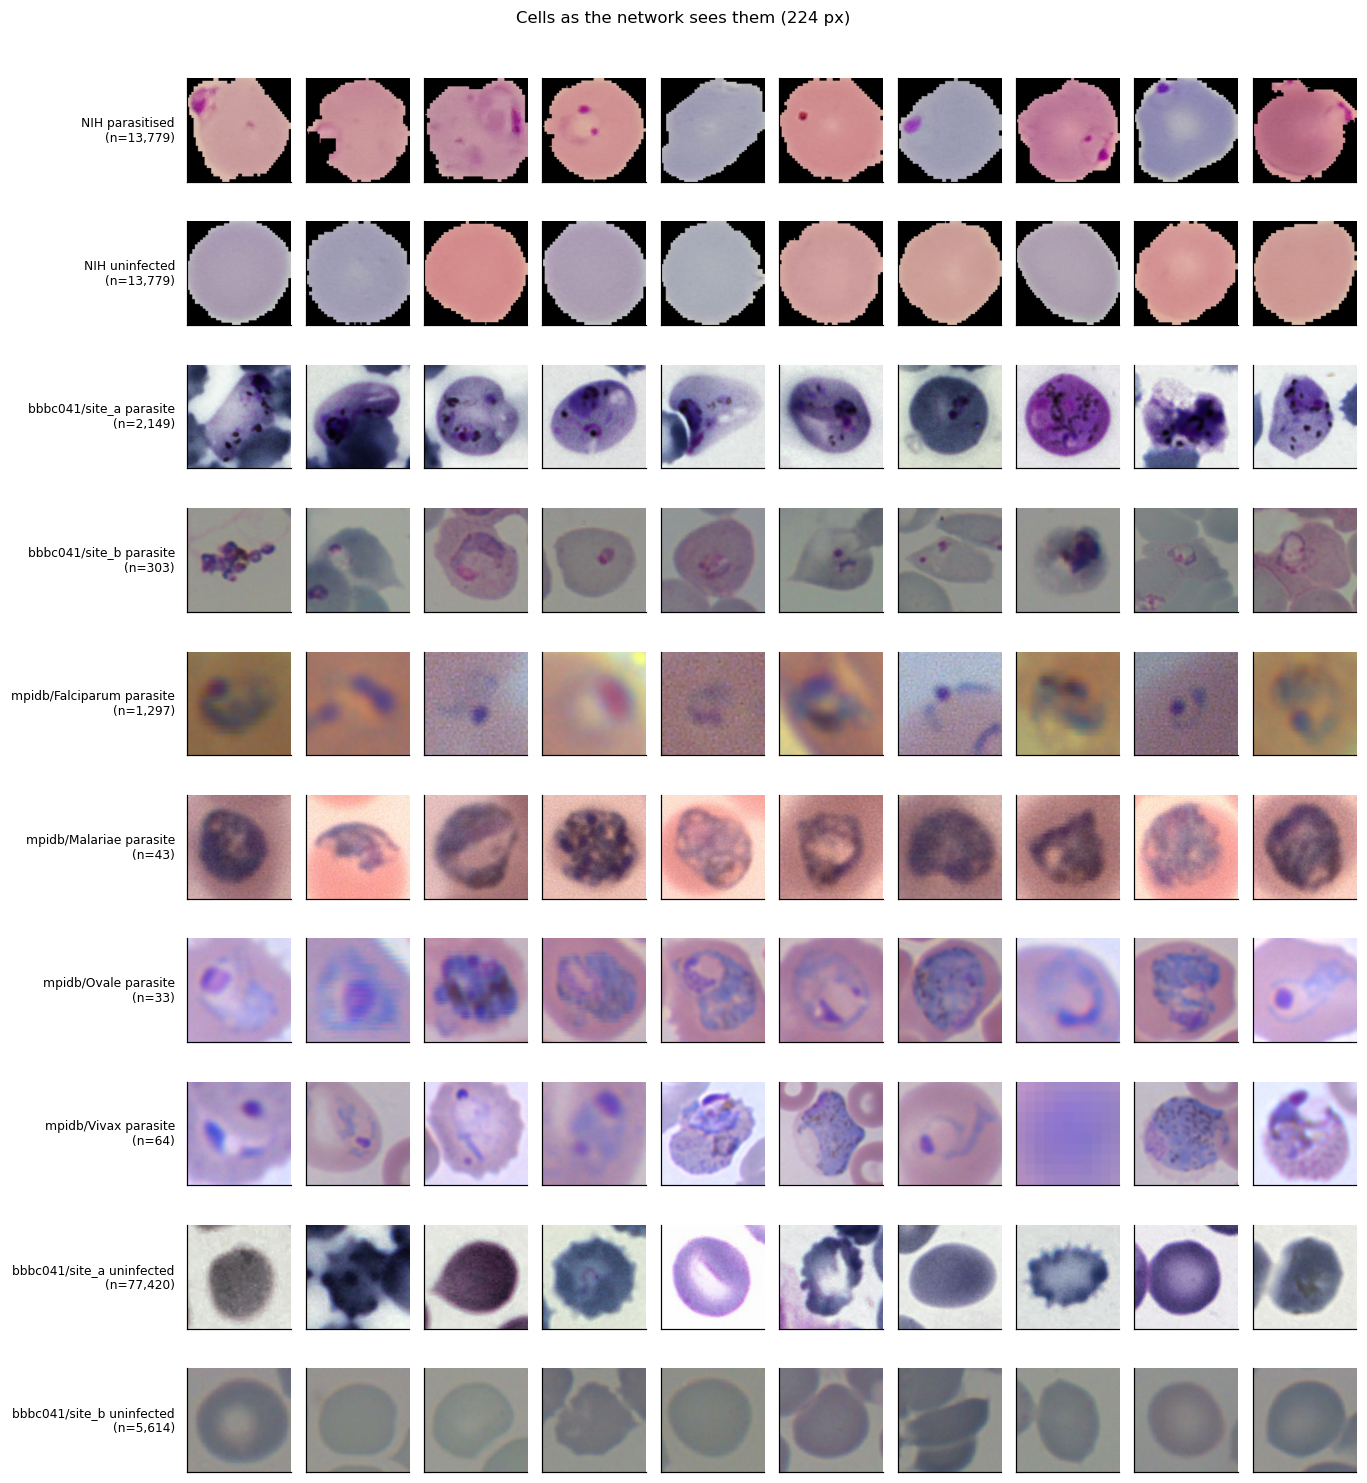

In [22]:
prim = stats[stats.eval_group == "primary"]
rows = [("NIH parasitised", prim[(prim.dataset == "nih") & (prim.label_binary == 1)]),
        ("NIH uninfected", prim[(prim.dataset == "nih") & (prim.label_binary == 0)])]
for d in plots.domains_in(prim):
    if d == "nih":
        continue
    sub = prim[(prim.domain.astype(str) == d) & (prim.label_binary == 1)]
    if len(sub):
        rows.append((f"{d} parasite", sub))
for d in ["bbbc041/site_a", "bbbc041/site_b"]:
    sub = prim[(prim.domain.astype(str) == d) & (prim.label_binary == 0)]
    if len(sub):
        rows.append((f"{d} uninfected", sub))

fig = plots.contact_sheet(rows, n=10,
                          title="Cells as the network sees them (224 px)")
plots.save(fig, "I_contact_sheet")

## J. Calibrating the RQ2 degradation levels

RQ2 sweeps blur, noise and contrast over the test images. Picking those severity
levels arbitrarily would make the results hard to interpret: a 15 px blur kernel
means nothing on its own. Instead the same degradations are applied to NIH crops
here and the resulting statistic is plotted against severity, with the real test
domains drawn as horizontal lines. Where a curve crosses a line is the severity
at which degraded NIH matches that dataset on that property, which turns the RQ2
levels into a statement about how much real-world shift each one represents.

In [23]:
import albumentations as A
import cv2

SAMPLE = 400
nih_sample = stats[stats.dataset == "nih"].sample(SAMPLE, random_state=0)
imgs = [cv2.cvtColor(cv2.imread(str(paths.ROOT / p)), cv2.COLOR_BGR2RGB)
        for p in nih_sample["path"]]
imgs = [cv2.resize(i, (paths.MODEL_INPUT, paths.MODEL_INPUT),
                   interpolation=cv2.INTER_AREA) for i in imgs]

from malaria.imagestats import _CENTER

def measure(batch):
    g = [cv2.cvtColor(i, cv2.COLOR_RGB2GRAY) for i in batch]
    hsv = [cv2.cvtColor(i, cv2.COLOR_RGB2HSV) for i in batch]
    lap = [cv2.Laplacian(x, cv2.CV_64F) for x in g]
    return {"lapvar224": float(np.median([x.var() for x in lap])),
            "lapvar224_center": float(np.median([x[_CENTER].var() for x in lap])),
            "gray_std": float(np.median([x.std() for x in g])),
            "gray_std_center": float(np.median([x[_CENTER].std() for x in g])),
            "gray_mean": float(np.median([x.mean() for x in g])),
            "sat_mean": float(np.median([h[..., 1].mean() for h in hsv]))}

sweeps = {
    # k=1 is the undegraded baseline, so each curve starts from where NIH sits
    "gaussian_blur": ([1, 3, 5, 7, 9, 11, 15, 21],
                      lambda k: A.NoOp(p=1.0) if k == 1
                      else A.GaussianBlur(blur_limit=(k, k), p=1.0)),
    "gauss_noise":   ([0.002, 0.005, 0.01, 0.02, 0.05, 0.1],
                      lambda v: A.GaussNoise(std_range=(v, v), p=1.0)),
    "contrast":      ([-0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4],
                      lambda c: A.RandomBrightnessContrast(
                          brightness_limit=(0, 0), contrast_limit=(c, c), p=1.0)),
}

recs = []
for name, (levels, make) in sweeps.items():
    for lv in levels:
        t = make(lv)
        out = [t(image=i)["image"] for i in imgs]
        recs.append({"degradation": name, "severity": lv, **measure(out)})
sweep = pd.DataFrame(recs)
sweep.to_csv(paths.TABLES / "rq2_severity_calibration.csv", index=False)
print(sweep.round(2).to_string(index=False))

  degradation  severity  lapvar224  lapvar224_center  gray_std  gray_std_center  gray_mean  sat_mean
gaussian_blur      1.00     573.95              6.16     73.27             5.22     117.31     47.30
gaussian_blur      3.00      86.76              2.34     72.18             5.11     117.30     48.26
gaussian_blur      5.00      28.01              1.92     71.56             5.11     117.30     49.01
gaussian_blur      7.00      15.85              1.77     71.02             5.08     117.29     49.71
gaussian_blur      9.00      14.29              1.72     70.79             5.07     117.30     49.65
gaussian_blur     11.00      12.37              1.66     70.70             5.06     117.30     50.68
gaussian_blur     15.00      15.23              1.71     70.55             5.15     117.30     49.96
gaussian_blur     21.00      12.29              1.68     70.53             5.08     117.30     50.76
  gauss_noise      0.00     574.69              6.86     73.26             5.22     117.31 

  saved outputs/figures/J_rq2_calibration.png


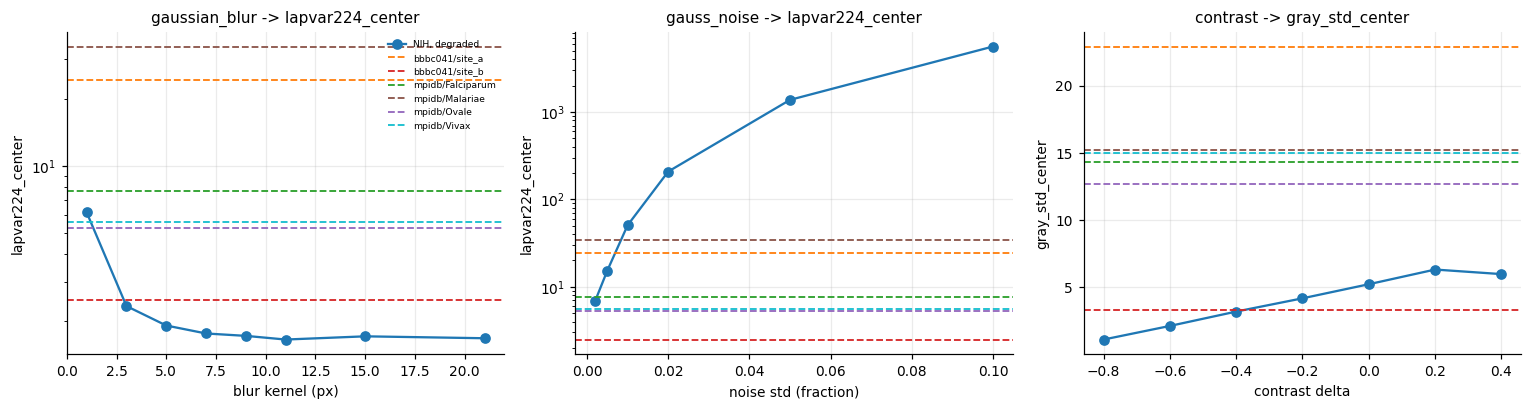

In [24]:
# Matched on the tissue-only statistics: the whole-crop sharpness of an NIH cell
# is pinned by its mask edge, which no amount of blurring removes, so matching on
# it would be matching on the segmentation rather than on the optics.
targets = (stats[stats.dataset != "nih"]
           .groupby("domain", observed=True)
           [["lapvar224_center", "gray_std_center"]].median())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
panels = [("gaussian_blur", "lapvar224_center", "blur kernel (px)", True),
          ("gauss_noise", "lapvar224_center", "noise std (fraction)", True),
          ("contrast", "gray_std_center", "contrast delta", False)]
for ax, (deg, stat, xlabel, logy) in zip(axes, panels):
    s = sweep[sweep.degradation == deg]
    ax.plot(s["severity"], s[stat], "o-", color=plots.DOMAIN_COLORS["nih"],
            label="NIH, degraded")
    for d, row in targets.iterrows():
        ax.axhline(row[stat], ls="--", lw=1.2,
                   color=plots.DOMAIN_COLORS.get(str(d)), label=str(d))
    if logy:
        ax.set_yscale("log")
    ax.set(xlabel=xlabel, ylabel=stat, title=f"{deg} -> {stat}")
axes[0].legend(fontsize=6, loc="upper right")
fig.tight_layout()
plots.save(fig, "J_rq2_calibration")

### Reading the calibration

The severity at which the NIH curve crosses a dashed line is the degradation that
reproduces, on that one statistic, the gap to that real dataset.

The result is not the one the proposal assumed, and it is worth stating plainly.

**Blur is close to useless as a domain proxy here.** Measured on tissue, NIH is
already among the least detailed domains (about 6, against 24 for BBBC041 site_a
and 34 for MP-IDB Malariae). Most test domains are *sharper* than the training
data, so blurring NIH moves away from them. Only site_b, Ovale and Vivax sit below
NIH, and they are reached with a small kernel before the curve flattens.

**Contrast has to rise to reach most domains.** NIH tissue contrast is about 5,
lower than every test domain except site_b at 3; the other five run from 13 to
23. Reducing contrast reaches only site_b. Raising it stops improving past about
+0.2 because highlights clip, and never reaches site_a at 23.

**Noise moves away from every domain.** It raises Laplacian variance where the
test sets sit lower, so its curve travels in the opposite direction. No dataset
here is noisy in that way.

So RQ2 should be reframed. Sweeping blur, noise and contrast still answers a
legitimate robustness question, namely how much degradation the model absorbs
before it breaks. It should not be presented as simulating the cross-dataset
shift, because the measured shift does not lie along those axes. The axes it does
lie along are stain colour, tissue brightness and crop format, and section H
ranks them.

## K. Summary table for the write-up

Brightness, contrast and sharpness are the tissue-only measurements, for the
reason given in section F: the whole-crop versions of all three describe the NIH
segmentation mask rather than the imaging, and reverse the direction of the
comparison.

In [25]:
summary = (stats.groupby("domain", observed=True)
           .agg(cells=("cell_id", "size"),
                median_width=("w", "median"),
                upscale=("upscale_factor", "median"),
                brightness=("gray_mean_center", "median"),
                contrast=("gray_std_center", "median"),
                saturation=("sat_mean", "median"),
                stain_rb=("rb_diff", "median"),
                sharpness=("lapvar224_center", "median"),
                black_frac=("black_frac", "median"))
           .round(2))
print(summary.to_string())
summary.to_csv(paths.TABLES / "domain_summary.csv")
print()
print(f"figures -> {paths.FIGURES}")
print(f"tables  -> {paths.TABLES}")

                  cells  median_width  upscale  brightness  contrast  saturation  stain_rb  sharpness  black_frac
domain                                                                                                           
nih               27558         130.0     1.61      164.21      5.06       45.33     29.10       6.05        0.26
bbbc041/site_a    80113         135.0     1.65       91.73     22.91       56.79    -24.00      24.18        0.00
bbbc041/site_b     5922         172.0     1.29      121.94      3.28       17.10     -1.59       2.49        0.00
mpidb/Falciparum   1297          78.0     2.87      123.69     14.31       76.88     42.74       7.72        0.00
mpidb/Malariae       43         126.0     1.78       98.55     15.18       67.51     33.04      34.22        0.00
mpidb/Ovale          33         138.0     1.62      138.34     12.64       60.65     -2.40       5.24        0.00
mpidb/Vivax          64         147.0     1.52      151.17     14.95       55.18    -18.

## L. Verification

Checks that the cached crops actually correspond to their manifest rows. These
run every time the notebook does, so a silent breakage in the crop pipeline shows
up here rather than in a model result three weeks later.

In [26]:
import cv2
import json
from malaria.crops import mask_components, read_gray_mask
from malaria.manifests import _pair_img_gt, _shipped_stage_map

man = load_manifest()

# 1. every crop referenced by the manifest exists and decodes
sample = man[man.dataset != "nih"].sample(400, random_state=0)
bad = [q for q in sample["path"] if cv2.imread(str(paths.ROOT / q)) is None]
assert not bad, bad[:5]
print("[ok] 400 sampled crops all decode")

# 2. crop dimensions on disk match the recorded crop window
mismatch = [r["cell_id"] for _, r in sample.iterrows()
            if cv2.imread(str(paths.ROOT / r["path"])).shape[:2]
            != (r["r1"] - r["r0"], r["c1"] - r["c0"])]
assert not mismatch, mismatch[:5]
print("[ok] crop dimensions match the recorded crop windows")

# 3. BBBC041 row count equals the number of annotated objects
n_obj = sum(len(rec["objects"]) for jf in paths.BBBC041_JSON.values()
            for rec in json.loads(jf.read_text()))
assert int((man.dataset == "bbbc041").sum()) == n_obj
print(f"[ok] BBBC041 rows == {n_obj:,} annotated objects")

# 4. MP-IDB crops reproduce the dataset authors' own parasite decomposition
n_checked = 0
for sp in ["Falciparum", "Vivax"]:
    shipped = _shipped_stage_map(sp)
    for stem, _img, gt in _pair_img_gt(sp):
        if stem in shipped:
            assert len(mask_components(read_gray_mask(gt))) == len(shipped[stem]), stem
            n_checked += 1
print(f"[ok] MP-IDB component counts match the shipped crops on {n_checked} images")

# 5. no NIH slide spans two splits, and the classes stay balanced
check_no_patient_leakage(nih_split)
rates = nih_split.groupby("split", observed=True)["label_binary"].mean()
assert rates.max() - rates.min() < 0.02, rates
print("[ok] no slide leakage; class balance within 2 points across splits")

[ok] 400 sampled crops all decode


[ok] crop dimensions match the recorded crop windows


[ok] BBBC041 rows == 86,035 annotated objects


[ok] MP-IDB component counts match the shipped crops on 144 images
[ok] no slide leakage; class balance within 2 points across splits


## M. What this changes

**Section 4.1 of the proposal needs a correction.** MP-IDB ships `crops/` for only
Falciparum and Vivax, and the two use different conventions: Falciparum crops are
background-masked and Vivax crops are not. All MP-IDB cells are therefore regenerated
from the `gt/` masks under the same rule as BBBC041. The expert stage labels are
preserved by matching left to right against the shipped crops, validated against
the authors' own decomposition on all 144 images that have one.

**The largest train/test difference is crop format, not imaging.** NIH cells are
segmented onto black; about a quarter of every NIH crop is padding. That single
fact dominates the ranked domain gap and inflates whole-crop brightness, contrast
and sharpness enough to reverse all three comparisons.

Colour is what genuinely separates the domains. The stain red-minus-blue axis runs
from +43 (MP-IDB Falciparum) through +29 (NIH) to -24 (BBBC041 site_a), a sign
reversal, and saturation and tissue brightness separate the domains cleanly. A
cheap classifier tells any test domain from NIH at AUC 1.00 from colour and tissue
features alone. Sharpness does the opposite: measured on tissue only it is nearly
identical across all seven domains, at a largest |d| of about 0.3, and several
test domains are sharper than NIH. That is why blur is the wrong axis for RQ2.
The sub-question survives as a robustness probe, but it can no longer be described
as simulating the cross-dataset shift.

**BBBC041 is two datasets.** site_a and site_b differ from each other about as
much as either differs from NIH, and are reported separately throughout.

**RQ3 is sample-size limited.** Sixteen stage/domain combinations have n < 30 and
nine have n < 10 (seven if the two `unknown`-stage rows are left out). Per-class
recall needs confidence intervals, and the smallest classes cannot support a claim
in either direction.

Three further things constrain what RQ3 can claim. The cells cluster within
images: 888 of the 1,208 site_a images and 115 of the 120 site_b images contain a
parasite, at a median of two per image, and the three rarer MP-IDB species are
almost all one parasite per image, so per-class intervals should be clustered by
source image rather than computed as if every cell were an independent trial.
Species recall is also confounded with resolution, because Falciparum rings are
small: their crops have a median side of 78 px (2.9x upscale) against 126 to
147 px for the other three species, so a recall difference between species is
partly a difference in how much detail the network was given. And twenty-nine
crops have a shortest side under 30 px, including one Vivax component of 10 by
11 px, which is too little to score fairly. Report RQ3 with and without those, in
the same way `difficult` cells are held out of the BBBC041 primary metric.

**Accuracy is the wrong headline metric on BBBC041.** The primary set is 2.7%
parasitised on site_a (2,149 of 79,569) and 5.1% on site_b (303 of 5,917), so a
model that calls everything uninfected scores 95 to 97%. Report sensitivity and
specificity separately, with F1 or PR-AUC at a fixed threshold, and keep accuracy
for NIH, where the classes are balanced.

**The EDA points augmentation at colour.** The measured shift is stain colour and
tissue brightness (section H), so training-time hue and saturation jitter plus
brightness shifts are the augmentations the data argues for. Blur augmentation
would rehearse a difference that does not exist between these datasets. The
proposal's "minor brightness adjustments" should be widened to include colour.

On volume, the training side is fine. 19,203 training cells is in line with the
published NIH experiments that reach above 95% from ImageNet-initialised backbones
(Rajaraman et al., 2018), and all three networks are fine-tuned rather than
trained from scratch. The binding constraint sits on the test side, in the small
RQ3 classes.

The split is clean of duplicates too. No NIH file appears twice, and the
perceptual hash matches that do exist join different patients and often different
classes, which marks them as look-alike discs rather than repeats. The few
within-patient candidates cannot cross the patient-grouped split.

**NIH is a single-species dataset.** Its 200 patients are 150 infected with
P. falciparum and 50 uninfected (Rajaraman et al., 2018), which is exactly the
150 mixed and 50 uninfected-only slides found in section B. Every Malariae, Ovale
and Vivax result in RQ3 is therefore species-out-of-distribution, on top of the
imaging shift.

**Next step.** `data/manifests/nih_split.csv` fixes the slide-grouped split, so
MobileNetV2, ResNet-50 and VGG-16 can be fine-tuned on identical rows.

## N. Answers to the Canvas EDA questions

The Canvas EDA activity asks for readiness to discuss a fixed list of questions at
the Week 3 supervision meeting. Each is answered here in a sentence or two, with
the section that supports it.

**Anomalies or unusual patterns.** The largest NIH-vs-test difference is crop
format, not imaging: a quarter of every NIH crop is black padding, which inflates
whole-crop brightness, contrast and sharpness enough to reverse all three
comparisons (F, G). BBBC041 is two acquisition batches that differ as much from
each other as from NIH (A, H). Fifty NIH patients contributed uninfected cells
only, and those cells are visibly less saturated (B).

**Data quality issues.** No missing labels in the primary sets. A `Thumbs.db` sits
in each NIH class folder; MP-IDB `gt/` and `img/` disagree on three filenames and
its shipped crops use two conventions, so every crop was regenerated under one
rule; 11 MP-IDB cells have an unresolvable stage and are labelled `unknown` (A, L,
`mpidb_stage_audit.csv`). No exact duplicates and no near-duplicate leakage (B).
Twenty-nine MP-IDB crops are under 30 px on a side and should be held out of RQ3
or reported separately (C).

**Risks in the data.** Class imbalance: BBBC041 is 2.7% and 5.1% parasitised and
MP-IDB has no negatives at all (A). Sparsity: sixteen stage/domain cells have
n < 30 and nine have n < 10 (A). Representativeness: NIH is P. falciparum only,
from one hospital, so the three other species in RQ3 are out of distribution (M),
and Falciparum crops are about half the size of the other species' crops (C).

**Implications for preprocessing.** Resize to 224 px from crops stored at native
size; one padded-square cropping rule for both test sets; no background masking of
test crops, so the NIH mask stays a measured train/test difference rather than a
hidden one; BBBC041 `difficult` and `leukocyte` held out of the primary metric
(A, G, `malaria/crops.py`).

**Implications for methodological choices.** Split NIH by patient, not at random
(B). Report site_a and site_b separately (A, H). Treat RQ2 as a robustness probe,
not a simulation of the cross-dataset shift (J). Augment colour and brightness in
training, not blur (M). Cluster RQ3 intervals by source image, and report
sensitivity and specificity rather than accuracy on BBBC041 (M).

**Data leakage risks.** Patient identity: removed by the grouped split and checked
by assertion (B, L). Slide appearance as a label shortcut: tested and found small;
colour alone reaches AUC 0.77 with or without the uninfected-only patients (B).
Duplicates across splits: none (B).

**Overall quality and suitability.** Good for the main question and RQ1: three
clean, labelled sources, 27,558 balanced training cells, and a domain shift that
is real and measurable (H). Adequate for RQ2 as a robustness question, weak for
RQ2 as a simulation of the real shift (J). Adequate for RQ3 on Falciparum and on
BBBC041 stages, and too thin for a per-class claim on Malariae, Ovale or Vivax, or
on any gametocyte group outside site_a (A).

**Patterns in the target and features.** NIH is balanced by construction, and
every infected patient also contributes uninfected cells (B). In the test sets the
target is rare and clustered, at about two parasites per positive image (A). Among
the features, the domains separate on stain colour and tissue brightness and
hardly at all on tissue sharpness (D, E, F, H).

**Enough observations for the model?** Yes on the training side: 19,203 training
cells fine-tuning ImageNet-initialised backbones, in line with the published NIH
experiments. The limit is on the test side, in the small RQ3 classes (M).

**A representative sample, inspected.** Section I shows ten cells per group at
network input size; section C adds the twenty smallest MP-IDB crops.

**Duplicates or near-duplicates, including across splits.** None exact; the
perceptual-hash matches are look-alike discs from different patients, and the
within-patient candidates cannot cross the split (B).

**Noisy or inconsistent labels.** BBBC041 `difficult` cells are excluded and
counted; every MP-IDB stage label carries its provenance (shipped crop,
single-stage filename, or ambiguous) in `mpidb_stage_audit.csv` (A). NIH labels
are binary, come from a single expert slide reader (Rajaraman et al., 2018), and
are taken as given; there is no second annotator to measure their noise against.

**Spurious correlations.** The black background is the strongest gradient in an
NIH image and is absent from every test set (G, H); a cheap classifier separates
any test domain from NIH at AUC 1.0 from colour alone (H); colour alone predicts
the NIH label at AUC 0.77, so headline NIH accuracy does not show that morphology
was learned (B).

**Does imbalance or volume call for augmentation?** Not for volume. For the
measured shift, yes: hue, saturation and brightness augmentation in training is
the mitigation the data points to; blur augmentation is not (M).

**Systematic quality differences across classes or groups.** Uninfected-only NIH
patients are less saturated than the rest (B); site_b is darker, flatter and
JPEG-compressed where site_a is PNG (D, F); Falciparum crops are 78 px against
126 to 147 px for the other species (C).